In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [9]:
DATASET_PATH = r"../road_dataset"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20

class_names = sorted(os.listdir(DATASET_PATH))
num_classes = len(class_names)

print(class_names)

['good', 'poor', 'satisfactory', 'very_poor']


In [11]:
X = []
y = []

for label, class_name in enumerate(class_names):
    class_path = os.path.join(DATASET_PATH, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0   # Normalize

        X.append(img)
        y.append(label)

X = np.array(X)
y = to_categorical(y, num_classes)

In [12]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [13]:
def build_model():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False  # Transfer Learning

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3),
]

In [15]:
fold_no = 1

for train_idx, val_idx in kfold.split(X):
    print(f"\nTraining Fold {fold_no}")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = build_model()

    checkpoint = ModelCheckpoint(
        f"road_condition_fold_{fold_no}.h5",
        monitor='val_accuracy',
        save_best_only=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks + [checkpoint]
    )

    fold_no += 1


Training Fold 1
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step
Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.6581 - loss: 0.8782

244/244 ━━━━━━━━━━━━━━━━━━━━ 156s 585ms/step - accuracy: 0.7600 - loss: 0.6163 - val_accuracy: 0.8964 - val_loss: 0.3099 - learning_rate: 1.0000e-04
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.8523 - loss: 0.3558

244/244 ━━━━━━━━━━━━━━━━━━━━ 118s 484ms/step - accuracy: 0.8753 - loss: 0.3168 - val_accuracy: 0.9026 - val_loss: 0.2401 - learning_rate: 1.0000e-04
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9050 - loss: 0.2642

244/244 ━━━━━━━━━━━━━━━━━━━━ 118s 484ms/step - accuracy: 0.9084 - loss: 0.2512 - val_accuracy: 0.9149 - val_loss: 0.2114 - learning_rate: 1.0000e-04
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9196 - loss: 0.2170

244/244 ━━━━━━━━━━━━━━━━━━━━ 146s 499ms/step - accuracy: 0.9184 - loss: 0.2117 - val_accuracy: 0.9272 - val_loss: 0.1903 - learning_rate: 1.0000e-04
Epoch 5/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 127s 439ms/step - accuracy: 0.9343 - loss: 0.1871 - val_accuracy: 0.9262 - val_loss: 0.1792 - learning_rate: 1.0000e-04
Epoch 6/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 126s 517ms/step - accuracy: 0.9376 - loss: 0.1683 - val_accuracy: 0.9262 - val_loss: 0.1697 - learning_rate: 1.0000e-04
Epoch 7/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.9414 - loss: 0.1583

...

244/244 ━━━━━━━━━━━━━━━━━━━━ 117s 441ms/step - accuracy: 0.7236 - loss: 0.6985 - val_accuracy: 0.8891 - val_loss: 0.3057 - learning_rate: 1.0000e-04
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.8623 - loss: 0.3804

244/244 ━━━━━━━━━━━━━━━━━━━━ 135s 552ms/step - accuracy: 0.8789 - loss: 0.3405 - val_accuracy: 0.9209 - val_loss: 0.2182 - learning_rate: 1.0000e-04
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.9099 - loss: 0.2620

244/244 ━━━━━━━━━━━━━━━━━━━━ 90s 369ms/step - accuracy: 0.9053 - loss: 0.2682 - val_accuracy: 0.9302 - val_loss: 0.1864 - learning_rate: 1.0000e-04
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.9104 - loss: 0.2402

244/244 ━━━━━━━━━━━━━━━━━━━━ 90s 370ms/step - accuracy: 0.9161 - loss: 0.2305 - val_accuracy: 0.9353 - val_loss: 0.1769 - learning_rate: 2.0000e-05
Epoch 5/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.9258 - loss: 0.2155

244/244 ━━━━━━━━━━━━━━━━━━━━ 140s 576ms/step - accuracy: 0.9215 - loss: 0.2202 - val_accuracy: 0.9374 - val_loss: 0.1716 - learning_rate: 2.0000e-05


In [16]:
y_pred = np.argmax(model.predict(X_val), axis=1)
y_true = np.argmax(y_val, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

31/31 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step 
              precision    recall  f1-score   support

        good       0.84      0.97      0.90       194
        poor       0.78      0.41      0.54       142
satisfactory       0.77      0.90      0.83       135
   very_poor       0.96      0.99      0.98       503

    accuracy                           0.89       974
   macro avg       0.84      0.82      0.81       974
weighted avg       0.88      0.89      0.88       974

[[188   5   0   1]
 [ 32  58  35  17]
 [  1  11 121   2]
 [  2   0   2 499]]


In [20]:
# Save full model (architecture + weights + optimizer)
model.save("pothole_mobilenetv2_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [26]:
from tensorflow.keras.models import load_model
import cv2
import numpy as np
import matplotlib.pyplot as plt

model = load_model("pothole_mobilenetv2_model.h5")

class_names = ['good', 'poor', 'satisfactory', 'very_poor']

In [27]:
def predict_road_condition(image_path):
    # Read image
    img = cv2.imread(image_path)
    
    if img is None:
        print("Error: Image not found or unreadable")
        return

    # Preprocess
    img_resized = cv2.resize(img, (224, 224))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # Prediction
    predictions = model.predict(img_input)
    class_index = np.argmax(predictions)
    confidence = predictions[0][class_index] * 100

    # Display
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Prediction: {class_names[class_index]} ({confidence:.2f}%)")
    plt.show()

    print("Predicted Class:", class_names[class_index])
    print("Confidence:", f"{confidence:.2f}%")

In [29]:
predict_road_condition("test1.jpg")

Error: Image not found or unreadable


In [ ]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    class_id = np.argmax(prediction)

    print("Predicted Class:", class_names[class_id])

In [30]:
def predict_road_condition_anywhere(image_path):
    # Convert to absolute path (works from anywhere)
    image_path = os.path.abspath(image_path)

    if not os.path.exists(image_path):
        print("❌ File does not exist:", image_path)
        return

    img = cv2.imread(image_path)

    if img is None:
        print("❌ Image cannot be read (unsupported format or corrupted)")
        return

    # Preprocess
    img_resized = cv2.resize(img, (224, 224))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # Predict
    preds = model.predict(img_input)
    class_index = np.argmax(preds)
    confidence = preds[0][class_index] * 100

    # Display image
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(
        f"Prediction: {class_names[class_index]}  |  Confidence: {confidence:.2f}%"
    )
    plt.show()

    print("✅ Predicted Class:", class_names[class_index])
    print("✅ Confidence:", f"{confidence:.2f}%")
    print("📂 Image Path:", image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


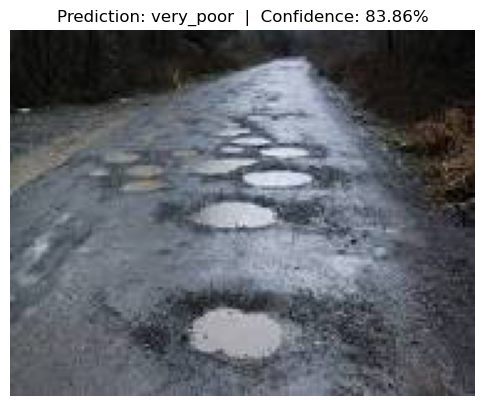

✅ Predicted Class: very_poor
✅ Confidence: 83.86%
📂 Image Path: c:\Users\KIIT0001\OneDrive\Desktop\project\test1.jpg


In [31]:
predict_road_condition_anywhere(
    r"../test1.jpg"
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


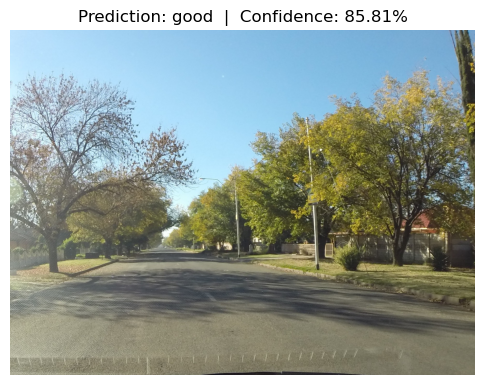

✅ Predicted Class: good
✅ Confidence: 85.81%
📂 Image Path: c:\Users\KIIT0001\OneDrive\Desktop\project\test.jpg


In [32]:
predict_road_condition_anywhere(
    r"../test.jpg"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


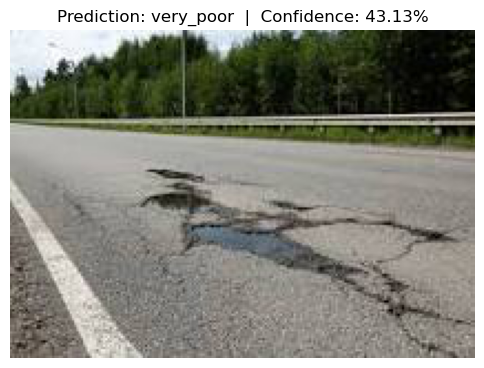

✅ Predicted Class: very_poor
✅ Confidence: 43.13%
📂 Image Path: c:\Users\KIIT0001\OneDrive\Desktop\project\test2.jpg


In [33]:
predict_road_condition_anywhere(
    r"../test2.jpg"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


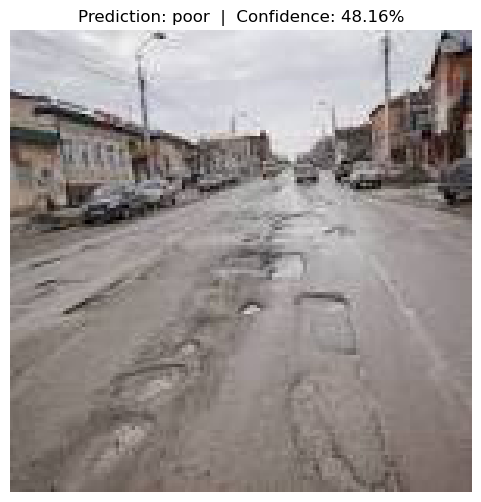

✅ Predicted Class: poor
✅ Confidence: 48.16%
📂 Image Path: c:\Users\KIIT0001\OneDrive\Desktop\project\test3.jpg


In [34]:
predict_road_condition_anywhere(
    r"../test3.jpg"
)